In [24]:
import numpy as np
import matplotlib.pyplot as plt

In [25]:
def _matlab_round_positive(z):
    """
    MATLAB-style rounding for positive numbers:
    round(0.5) -> 1.
    """
    return np.floor(z + 0.5).astype(int)


def wassersi(x, y, M=10, gfx=False):
    """
    WASSERSI Sensitivity indices using 1D Wasserstein distances.

    Parameters
    ----------
    x : array-like, shape (n, k)
        Input sample matrix. Rows are observations, columns are inputs.

    y : array-like, shape (n,)
        Output sample.

    M : int, optional
        Number of conditioning bins. Default is 10.

    gfx : bool, optional
        If True, produces diagnostic plots of unconditional vs conditional
        output quantiles.

    Returns
    -------
    W : dict
        Dictionary with Wasserstein sensitivity indices:
            W["W1"]
            W["W2"]
            W["W22"]
            W["W8"]
            W["Winf"]

    d : ndarray, shape (M, k)
        Binwise squared Wasserstein-2 distances.

    nn : ndarray, shape (M,)
        Number of observations in each bin.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    if x.ndim == 1:
        x = x.reshape(-1, 1)

    n, k = x.shape

    if len(y) != n:
        raise ValueError("x and y must have the same number of observations.")

    # Sort each input column and keep sorting indices
    xs = np.sort(x, axis=0)
    ix = np.argsort(x, axis=0)

    # Sorted unconditional output
    ys = np.sort(y)

    # Bin boundaries, matching the MATLAB logic:
    # Ms = round(linspace(1,n+1,M+1));
    # ii = Ms(m):Ms(m+1)-1;
    Ms = _matlab_round_positive(
        np.linspace(1, n + 1, M + 1)
    ) - 1

    Ms[0] = 0
    Ms[-1] = n

    d = np.zeros((M, k))
    e = np.zeros((M, k))
    f = np.zeros((M, k))
    g = np.zeros((M, k))
    nn = np.zeros(M, dtype=int)

    if gfx:
        L = np.sqrt(k)
        rows = int(np.floor(L))
        cols = int(np.ceil(L))

        if rows * cols < k:
            rows = int(np.ceil(L))

        colors = plt.cm.jet(np.linspace(0, 1, M))
        fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))

        axes = np.asarray(axes).reshape(-1)

    for m in range(M):

        ii = np.arange(Ms[m], Ms[m + 1])
        N = len(ii)
        nn[m] = N

        if N == 0:
            continue

        # MATLAB:
        # jj = round(linspace(.5,N+.499,n));
        # Python: convert to 0-based indices
        jj = _matlab_round_positive(
            np.linspace(0.5, N + 0.499, n)
        ) - 1

        jj = np.clip(jj, 0, N - 1)

        for i in range(k):

            # Conditional output sample:
            # y values corresponding to observations in bin m
            # after sorting x_i
            yc = np.sort(y[ix[ii, i]])

            # Scale yc up to size n by quantile replication
            ycc = yc[jj]

            diff = ys - ycc

            d[m, i] = np.mean(diff**2)
            e[m, i] = np.mean(np.abs(diff))
            f[m, i] = np.max(np.abs(diff))
            g[m, i] = np.mean(diff**8)**(1 / 8)

            if gfx:
                ax = axes[i]
                ax.plot(
                    ys,
                    ycc,
                    color=colors[m],
                    linewidth=2
                )
                ax.set_xlabel("Output")
                ax.set_ylabel("Conditional outputs")
                ax.set_title(f"$x_{{{i+1}}}$")

    if gfx:
        for j in range(k, len(axes)):
            axes[j].axis("off")

        plt.tight_layout()
        plt.show()

    # MATLAB uses matrix multiplication:
    # W.W2   = nn * sqrt(d) / n
    # W.W22  = nn * d       / n
    # W.W1   = nn * e       / n
    # W.W8   = nn * g       / n
    # W.Winf = nn * f       / n
    #
    # Therefore each W index is a vector of length k.
    weights = nn.astype(float)

    W = {
        "W2": weights @ np.sqrt(d) / n,
        "W22": weights @ d / n,
        "W1": weights @ e / n,
        "W8": weights @ g / n,
        "Winf": weights @ f / n
    }

    return W, d, nn

In [26]:
def plot_w22(W, Y, variable_names=None):

    varY = np.var(Y, ddof=1)

    iota = W["W22"] / (2 * varY)

    k = len(iota)

    if variable_names is None:
        variable_names = [
            f"x{i+1}"
            for i in range(k)
        ]

    idx = np.argsort(iota)[::-1]

    iota = iota[idx]
    names = [variable_names[i] for i in idx]

    y = np.arange(k)

    plt.figure(figsize=(8,4))

    plt.barh(
        y,
        iota,
        color="steelblue"
    )

    plt.yticks(y, names)

    plt.xlabel(r"$\iota_i$")

    plt.title(
        r"Wasserstein Sensitivity Index "
        r"$W_2^2/(2V(Y))$"
    )

    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

In [27]:
def mysqrtm(A):
    """
    Robust symmetric matrix square root using SVD.
    Equivalent in spirit to the MATLAB mysqrtm function.
    """

    A = np.asarray(A, dtype=float)

    if A.ndim == 0:
        return np.sqrt(max(A, 0.0))

    U, s, Vt = np.linalg.svd(A, full_matrices=False)

    return U @ np.diag(np.sqrt(np.maximum(s, 0.0))) @ Vt

In [28]:
def bwsi(x, y, M=8, sigma=0):
    """
    Bures-Wasserstein sensitivity indices.

    Parameters
    ----------
    x : array-like, shape (n, k)
        Input sample matrix.

    y : array-like, shape (n,) or (n, l)
        Output sample. If y is univariate, the Bures distance reduces
        to the squared Fréchet distance between Gaussian approximations.

    M : int
        Number of conditioning bins.

    sigma : float
        Entropic regularization parameter. If sigma=0, Sinkhorn part is skipped.

    Returns
    -------
    result : dict
        Dictionary containing:

        Wass2      : average Bures-Wasserstein distance, mean over bins of sqrt(W)
        WassSep   : binwise squared Bures-Wasserstein distances
        SinkSep   : binwise Sinkhorn-like distances, if sigma != 0
        Mean2Sep  : binwise squared mean-distance components
        VarSep    : binwise variance/covariance components
        nn         : bin counts
    """

    x = np.asarray(x, dtype=float)

    if x.ndim == 1:
        x = x.reshape(-1, 1)

    y = np.asarray(y, dtype=float)

    if y.ndim == 1:
        y = y.reshape(-1, 1)

    n, k = x.shape
    ny, l = y.shape

    if ny != n:
        raise ValueError("x and y must have the same number of rows.")

    # Unconditional mean and covariance
    my = np.mean(y, axis=0)

    if l == 1:
        Cy = np.var(y[:, 0], ddof=1)
        Ry = np.sqrt(Cy)
    else:
        Cy = np.cov(y, rowvar=False)
        Ry = mysqrtm(Cy)

    # Sorting indices for each input
    ix = np.argsort(x, axis=0)

    # Bin boundaries, corresponding to MATLAB:
    # ms = round(linspace(0,n,M+1))
    ms = np.round(np.linspace(0, n, M + 1)).astype(int)
    ms[0] = 0
    ms[-1] = n

    W = np.zeros((M, k))
    S = np.zeros((M, k))
    Ms = np.zeros((M, k))
    VarSep = np.zeros((M, k))
    nn = np.zeros(M, dtype=int)

    for m in range(M):

        start = ms[m]
        end = ms[m + 1]

        nn[m] = end - start

        for i in range(k):

            # Conditional output sample for bin m of input i
            rows = ix[start:end, i]
            yc = y[rows, :]

            mc = np.mean(yc, axis=0)

            # --------------------------------------------------
            # Multivariate output
            # --------------------------------------------------
            if l > 1:

                Cc = np.cov(yc, rowvar=False)

                mean_sq_dist = np.sum((my - mc)**2)

                trace_term = (
                    np.trace(Cy)
                    + np.trace(Cc)
                    - 2 * np.trace(mysqrtm(Ry @ Cc @ Ry))
                )

                Ms[m, i] = mean_sq_dist
                VarSep[m, i] = trace_term
                W[m, i] = mean_sq_dist + trace_term

                if sigma != 0:

                    D = mysqrtm(
                        4 * Ry @ Cc @ Ry
                        + sigma**4 * np.eye(Cy.shape[0])
                    )

                    trace_terms = (
                        np.trace(Cy)
                        + np.trace(Cc)
                        - np.trace(D)
                    )

                    A = D + sigma**2 * np.eye(Cy.shape[0])

                    sign, logdetA = np.linalg.slogdet(A)

                    if sign <= 0:
                        logdetA = np.nan

                    entropic_terms = sigma**2 * (
                        Cy.shape[0] * (1 - np.log(2 * sigma**2))
                        + logdetA
                    )

                    S[m, i] = mean_sq_dist + trace_terms + entropic_terms

            # --------------------------------------------------
            # Scalar output
            # --------------------------------------------------
            else:

                yc1 = yc[:, 0]

                mc = np.mean(yc1)
                Cc = np.var(yc1, ddof=1)

                mean_sq_dist = (my[0] - mc)**2

                # Scalar Bures / Fréchet covariance component
                trace_term = Cy + Cc - 2 * np.sqrt(Ry * Cc * Ry)

                Ms[m, i] = mean_sq_dist
                VarSep[m, i] = trace_term
                W[m, i] = mean_sq_dist + trace_term

    Wass2 = np.mean(np.sqrt(np.maximum(W, 0.0)), axis=0)

    result = {
        "Wass2": Wass2,
        "WassSep": W,
        "SinkSep": S,
        "Mean2Sep": Ms,
        "VarSep": VarSep,
        "nn": nn
    }

    return result

In [29]:
def model(x):
    #Ishigami function
    a = 7
    b = 0.1
    return (np.sin(x[0])+ a * np.sin(x[1]) ** 2+b * x[2] ** 4 * np.sin(x[0]))

In [30]:
def plot_bures_wasserstein_comparison(
    bw_result,
    W,
    Y,
    variable_names=None
):

    varY = np.var(Y, ddof=1)

    MeanComponent = (
        np.mean(
            bw_result["Mean2Sep"],
            axis=0
        )
        /(2*varY)
    )

    Bures = (
        np.mean(
            bw_result["WassSep"],
            axis=0
        )
        /(2*varY)
    )

    Iota = (
        W["W22"]
        /(2*varY)
    )

    k = len(Iota)

    if variable_names is None:
        variable_names = [
            f"x{i+1}"
            for i in range(k)
        ]

    xpos = np.arange(k)

    width = 0.25

    plt.figure(figsize=(10,5))

    plt.bar(
        xpos-width,
        MeanComponent,
        width,
        label="Mean contribution",
        color="orange"
    )

    plt.bar(
        xpos,
        Bures,
        width,
        label="Bures / Fréchet",
        color="steelblue"
    )

    plt.bar(
        xpos+width,
        Iota,
        width,
        label=r"$\iota_i$",
        color="darkgreen"
    )

    plt.xticks(
        xpos,
        variable_names
    )

    plt.ylabel(
        "Normalized sensitivity"
    )

    plt.title(
        "Distribution-Based Sensitivity Measures"
    )

    plt.legend()

    plt.tight_layout()
    plt.show()

    return {
        "MeanContribution": MeanComponent,
        "Bures": Bures,
        "Iota": Iota
    }

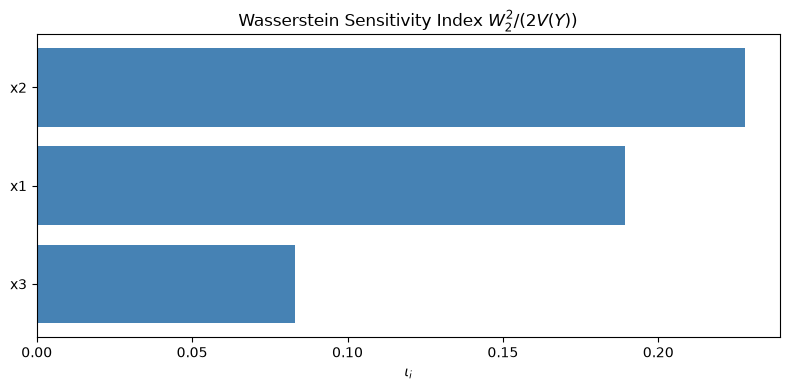

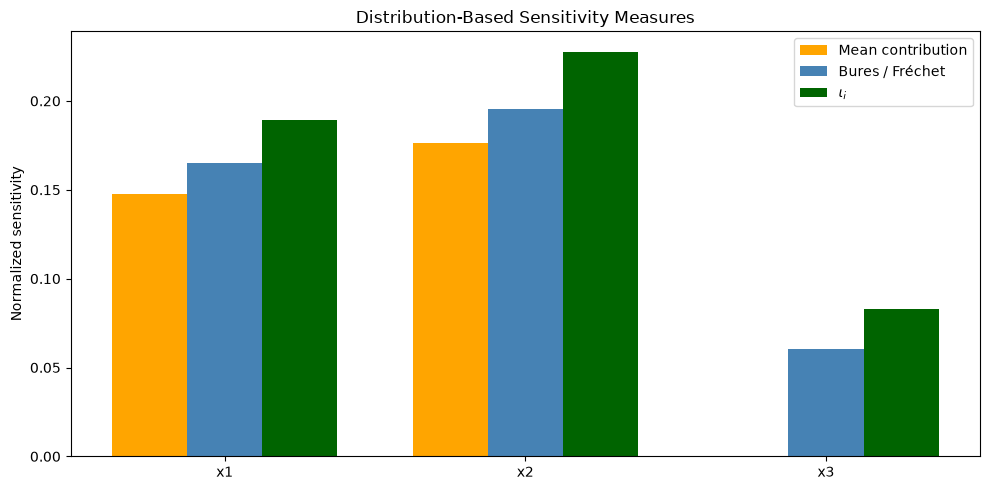

Mean contribution: [1.47773380e-01 1.76341319e-01 5.15260014e-05]
Bures: [0.16490805 0.19548856 0.06015007]
Iota: [0.18915624 0.22777154 0.08308266]


In [31]:
# =====================================================
# ISHIGAMI EXAMPLE
# =====================================================
N=50000
X = np.random.uniform(
    -np.pi,
    np.pi,
    size=(N,3)
)

Y = np.array([
    model(x)
    for x in X
])

variable_names = [
    "x1",
    "x2",
    "x3"
]

# Wasserstein
W, d, nn = wassersi(X, Y)

# Bures / Fréchet
bw_result = bwsi(X, Y)

# W22 only
plot_w22(
    W,
    Y,
    variable_names
)

# comparison plot
indices = plot_bures_wasserstein_comparison(
    bw_result,
    W,
    Y,
    variable_names
)

print("Mean contribution:",
      indices["MeanContribution"])

print("Bures:",
      indices["Bures"])

print("Iota:",
      indices["Iota"])
